<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Métodos Predictivos**

### Cátedra: Bianco

#### **Regresión Logística**


## Arboles de decisión

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
# Cargamos el dataset TITANIC directamente desde la librería seaborn
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Diccionario de Variables: Dataset Titanic**

* survived: Variable Objetivo ($Y$). Indica si el pasajero sobrevivió ($1$) o no ($0$).

* pclass: Clase del pasajero. Representa el estatus socioeconómico ($1^{ra}, 2^{da}, 3^{ra}$).

* sex: Género. Variable categórica binaria (male, female).

* age: Edad. Variable numérica continua ($Age \in \mathbb{R}^{+}$).

* sibsp: Hermanos/Cónyuges. Cantidad de familiares de la misma generación a bordo ($n \in \mathbb{Z}_{\geq 0}$).

* parch: Padres/Hijos. Cantidad de familiares de distinta generación a bordo ($n \in \mathbb{Z}_{\geq 0}$).

* fare: Tarifa. Precio pagado por el ticket ($Fare > 0$).


* embarked: Puerto de embarque. Ciudad donde subió el pasajero ($C = \text{Cherbourg}$, $Q = \text{Queenstown}$, $S = \text{Southampton}$).

* class: Clase (Texto). Equivalente nominal a la clase del pasajero (First, Second, Third).

* who: Categoría biológica. Clasificación en man, woman o child.

* adult_male: Adulto Hombre. Indica si el pasajero es un varón adulto ($\text{True}/\text{False}$).

* deck: Cubierta. Letra que identifica la sección del barco ($A, B, C, D, E, F, G$).

* embark_town: Ciudad de embarque. Nombre completo del puerto de origen.

* alive: Estado de vida. Versión categórica de la supervivencia (yes, no).

* alone: Viaja solo. Indica si el pasajero no tiene familiares registrados a bordo ($\text{True}/\text{False}$).


### Pretratamiento

In [3]:
# Verificamos cuántos nulos hay por columna
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
# Imputamos la mediana en la edad (podríamos tomar el promedio, pero la mediana suele ser más robusta y menos sensible a outliers)
df['age'] = df['age'].fillna(df['age'].median())

# Eliminamos la columna 'deck' porque tiene demasiados nulos para ser útil
df.drop(columns=['deck'], inplace=True)

# Eliminamos las filas con nulos en 'embarked' (son solo 2)
df.dropna(subset=['embarked'], inplace=True)

# Verificamos nuevamente
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [5]:
# Eliminamos columnas que repiten información y podrían traer multicolinealidad.
cols_to_drop = ['alive', 'class', 'who', 'adult_male', 'embark_town', 'alone']
df.drop(columns=cols_to_drop, inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
# Definimos el Target (La variable objetivo)
y = df['survived']

# Definimos las Features (Las variables predictoras)
# Eliminamos 'survived' porque es lo que queremos que el modelo aprenda a adivinar
X = df.drop(columns=['survived'])

# Ahora aplicamos las Dummies sobre X
# Al hacerlo después del drop, nos aseguramos de que 'survived' no se transforme en nada
X = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=False)

In [7]:
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_female  sex_male  embarked_C  \
0       3  22.0      1      0   7.2500       False      True       False   
1       1  38.0      1      0  71.2833        True     False        True   
2       3  26.0      0      0   7.9250        True     False       False   
3       1  35.0      1      0  53.1000        True     False       False   
4       3  35.0      0      0   8.0500       False      True       False   

   embarked_Q  embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [8]:
print(df['survived'].value_counts())

survived
0    549
1    340
Name: count, dtype: int64


### Modelo



In [9]:
# Instanciamos con una profundidad que podamos explicar (max_depth=3)
clf = DecisionTreeClassifier(max_depth=3,  criterion='gini', random_state=42) # class_weight='balanced',

# El modelo busca patrones en X que expliquen lo que pasó en y
clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

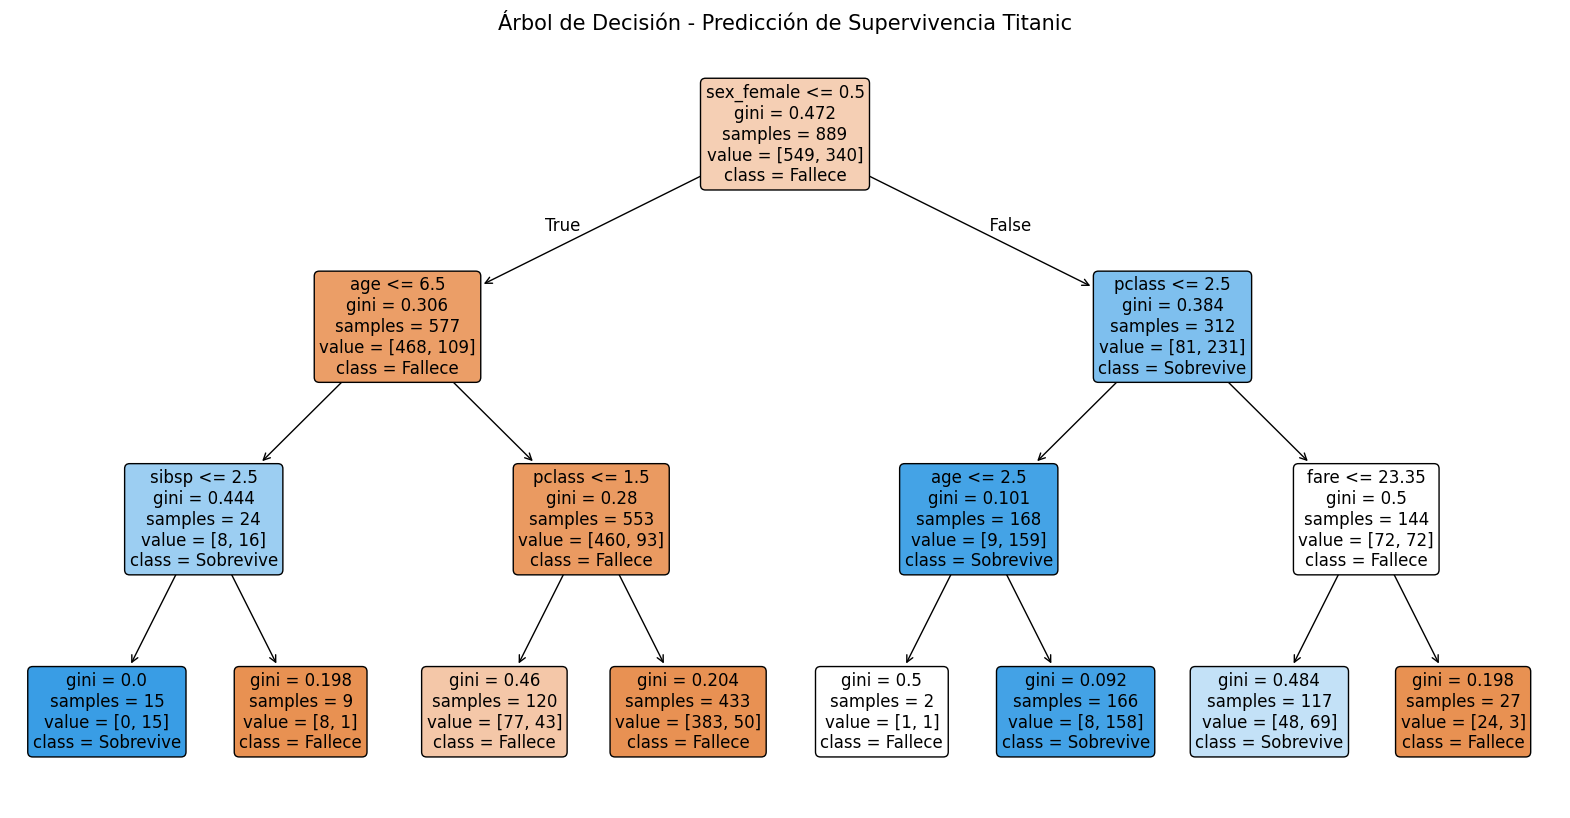

In [10]:
plt.figure(figsize=(20, 10))

# Generamos el gráfico
plot_tree(clf,
          feature_names=X.columns,       # Nombre de las variables
          class_names=['Fallece', 'Sobrevive'], # Etiquetas de la predicción
          filled=True,                   # Colorea los nodos según la clase dominante
          rounded=True,                  # Bordes redondeados para estética
          fontsize=12)                   # Tamaño de letra legible

plt.title("Árbol de Decisión - Predicción de Supervivencia Titanic", fontsize=15)
plt.show()

__Observen los colores:__

Nodos Naranjas: Representan grupos donde la mayoría fallece.

Nodos Azules: Representan grupos donde la mayoría sobrevive.

Intensidad del color: Cuanto más oscuro es el color, más bajo es el Gini (más "puro" es el nodo). Un azul fuerte es un grupo con una altísima tasa de supervivencia.

En el primer nodo (raíz). ¿Qué variable eligió el modelo como la más importante de todas? ¿Coincide con lo que pensábamos al principio de la Regresión Logística?

In [11]:
# Creamos una función para no repetir código y asegurar el orden de las columnas
def predecir_pasajero(modelo, datos_lista):
    # Convertimos a DataFrame para que scikit-learn no se queje de los nombres de columnas
    pasajero_df = pd.DataFrame([datos_lista], columns=X.columns)
    prediccion = modelo.predict(pasajero_df)[0]
    # También podemos obtener la probabilidad (Gini nos da la proporción en la hoja)
    prob = modelo.predict_proba(pasajero_df)[0][1]

    resultado = "SOBREVIVE" if prediccion == 1 else "NO SOBREVIVE"
    return resultado, prob

In [12]:
# 2. Definimos los personajes (siguiendo el orden de X)
# [pclass, age, sibsp, parch, fare, sex_female, sex_male, emb_C, emb_Q, emb_S]

# Juan Perez: 3ra clase, 30 años, viaja solo, pagó poco (7.25), hombre, salió de Southampton
juan = [3, 30, 0, 0, 7.25, 0, 1, 0, 0, 1]

# Jack Dawson: 3ra clase, 20 años, viaja solo, pagó 0 (ganó el ticket), hombre, salió de Southampton
jack = [3, 20, 0, 0, 0.0, 0, 1, 0, 0, 1]

# Rose DeWitt Bukater: 1ra clase, 17 años, con 1 familiar (madre), pagó mucho (150), mujer, salió de Cherbourg
rose = [1, 17, 1, 0, 150.0, 1, 0, 1, 0, 0]

# 3. Ejecutamos y mostramos resultados
for nombre, datos in zip(["Juan Perez", "Jack Dawson", "Rose DeWitt Bukater"], [juan, jack, rose]):
    res, prob = predecir_pasajero(clf, datos)
    print(f"--- {nombre} ---")
    print(f"Resultado: {res}")
    print(f"Probabilidad según pureza del nodo: {prob:.2%}\n")

--- Juan Perez ---
Resultado: NO SOBREVIVE
Probabilidad según pureza del nodo: 11.55%

--- Jack Dawson ---
Resultado: NO SOBREVIVE
Probabilidad según pureza del nodo: 11.55%

--- Rose DeWitt Bukater ---
Resultado: SOBREVIVE
Probabilidad según pureza del nodo: 95.18%



In [13]:
# Generamos las predicciones sobre el mismo set de entrenamiento
y_pred = clf.predict(X)

# Calculamos las métricas
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

# La Matriz de Confusión para ver dónde se equivoca
print("\nMatriz de Confusión:")
print(confusion_matrix(y, y_pred))


Accuracy: 82.68%
Precision: 81.21%
Recall: 71.18%

Matriz de Confusión:
[[493  56]
 [ 98 242]]


**Con un accurracy de 82.68%**, se puede decir que de cada 100 pasajeros, el modelo clasifica correctamente a unos 83 (tanto supervivientes como no supervivientes). Es un valor alto, pero en datasets desbalanceados puede ser engañoso. En el Titanic (≈60% no supervivientes), un modelo "tonto" que siempre predijera "muerto" tendría un 60% de accuracy. El 82.68% es claramente mejor.

**Precision 81.21%:** cuando el modelo predice que alguien sobrevive, acierta en el 81% de los casos. Es decir, de cada 10 predicciones de "superviviente", aproximadamente 2 son falsos positivos (personas que en realidad murieron). El modelo es fiable cuando dice que alguien vive.

**El recall de 71.18%**: de todos los verdaderos supervivientes que había en los datos, el modelo logró identificar al 71%. El 29% restante (falsos negativos) los clasificó erróneamente como "no supervivientes".

**Entrenamiento con todos los datos ¿tendría que acertar el 100% de los casos?**

El modelo a partir de un conjunto de datos genera un arbol y luego supone X1 o X2. Y genera una **Suposición**
Por ej.: supongamos que tenemos dos pasajeros en el dataset que son exactamente iguales para el árbol:

Pasajero A: Hombre, 3ra clase, 25 años. (Realidad: Falleció)

Pasajero B: Hombre, 3ra clase, 25 años. (Realidad: Sobrevivió)

Para el árbol, estos dos individuos son indistinguibles. Si el árbol decide que ese camino lleva a "Fallece" (porque quizás había 100 como ellos y murieron 80), al Pasajero B lo va a clasificar mal siempre. El error nace de que las variables que tenemos no alcanzan para explicar el 100% de la realidad.

**La Hoja es un "Promedio de Votos"**
Es necesario recordar que lo que vimos del Valor (Value) en cada cuadro del plot_tree:

Si una hoja tiene value = [40, 5], el árbol dice: "Aquí la mayoría (40) murió, así que la respuesta para todos los que lleguen aquí es FALLECE".

Esos 5 que realmente sobrevivieron son los que generan el error en la matriz de confusión. El árbol "sacrifica" a esos 5 en favor de la regla general.

**El Límite de la Profundidad**
Como nosotros le pusimos un max_depth=3, obligamos al árbol a detenerse y "generalizar".

Si le diéramos profundidad infinita, el árbol seguiría preguntando hasta que cada pasajero tenga su propia ramita (un árbol gigante).

El problema: Ahí tendríamos 100% de Accuracy en el entrenamiento, pero habríamos creado un modelo "maniático" que no serviría para predecir a nadie nuevo.

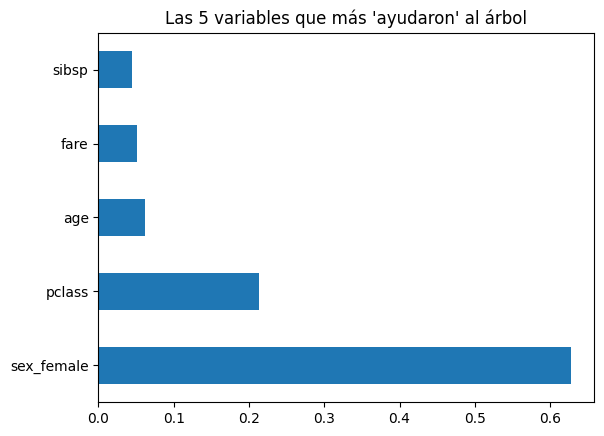

In [14]:
# Creamos un pequeño gráfico de barras con la importancia de cada variable
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh')
plt.title("Las 5 variables que más 'ayudaron' al árbol")
plt.show()

Por mucho la variable que más colabora para saber si el pasajero sobrevivió o no es sex_famale. El precio del ticket / la clase, practicamente son iguales. Luego, la edad y más atras si hay parentezco.

### Entrenamiento a ciegas

In [15]:
# Dividimos el set de datos (80% entrenamiento, 20% testeo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de testeo: {len(X_test)}")

Muestras de entrenamiento: 711
Muestras de testeo: 178


Para cualquier modelo siempre recurrir a la documentación de la librería:

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

nos va a permitir indagar acerca de funcionamiento y parámetros.

In [16]:
# --- CONFIGURACIÓN DE HIPERPARÁMETROS ---
# max_depth: Profundidad máxima (evita que el árbol crezca al infinito)
# class_weight: 'balanced' ayuda si hay más muertos que sobrevivientes
# min_samples_split: Cuántos datos mínimos se necesitan para abrir una nueva rama
# max_leaf_nodes: Límite máximo de "hojas" (nodos finales) para simplificar el árbol
# criterion: 'gini' o 'entropy' (la forma en que mide la impureza)

clf = DecisionTreeClassifier(
    max_depth=15,               # Valor por defecto: None (sin límite, crece hasta todas las hojas puras o con min_samples_split)
    # class_weight='balanced',   # Valor por defecto: None (todas las clases tienen peso = 1), balanced
    # min_samples_split=10,      # Valor por defecto: 2 (puede dividir con solo 2 muestras)
    # max_leaf_nodes=8,          # Valor por defecto: None (sin límite, crece todas las hojas posibles)
    criterion='gini',          # Valor por defecto: 'gini' (la otra opción es 'entropy')
    random_state=42
)

# Entrenamos solo con el set de entrenamiento
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [17]:
# Realizamos las predicciones sobre el set de TEST
y_pred = clf.predict(X_test)

# Calculamos las métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("--- MÉTRICAS EN EL TEST SET (A CIEGAS) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

--- MÉTRICAS EN EL TEST SET (A CIEGAS) ---
Accuracy:  74.72%
Precision: 65.79%
Recall:    72.46%


In [18]:
y_pred_train = clf.predict(X_train)

Comparemos que sucede con la comparación de métricas en train y test.

In [19]:
# Calculamos las métricas
accuracy_t = accuracy_score(y_train, y_pred_train)
precision_t = precision_score(y_train, y_pred_train)
recall_t = recall_score(y_train, y_pred_train)

print("---------------------------------------------------------")
print("--- MÉTRICAS EN EL TRAIN  ---")
print(f"Accuracy Train:  {accuracy_t:.2%}")
print(f"Precision Train: {precision_t:.2%}")
print(f"Recall Train:    {recall_t:.2%}")
print("---------------------------------------------------------")
print("--- MÉTRICAS EN EL TEST SET (A CIEGAS) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")


---------------------------------------------------------
--- MÉTRICAS EN EL TRAIN  ---
Accuracy Train:  97.19%
Precision Train: 99.22%
Recall Train:    93.36%
---------------------------------------------------------
--- MÉTRICAS EN EL TEST SET (A CIEGAS) ---
Accuracy:  74.72%
Precision: 65.79%
Recall:    72.46%


In [20]:
# 4. Matriz de Confusión de Entrenamiento (opcional para comparar errores)
print("\nMatriz de Confusión - Entrenamiento:")
print(confusion_matrix(y_train, y_pred_train))

print("\nMatriz de Confusión - Test:")
print(confusion_matrix(y_test, y_pred))



Matriz de Confusión - Entrenamiento:
[[438   2]
 [ 18 253]]

Matriz de Confusión - Test:
[[83 26]
 [19 50]]
